# Reward Gap Summary Tables

This notebook reads the copied reward-gap logs from `logs/sim2real_rewards/<agent>/<network>/<method>/<setting>` (the `baseline_rewards_v2` runs, 2026-07-06..10, plus the `oracle_v1` reward-oracle runs, 2026-07-21) and builds:

1. **Headline table — `R_real` at `REAL_TEST`** per (agent, network, setting, method). `direct_transfer` is the pretrained sim policy dropped into real with zero adaptation, so its `R_real` is what sim-training alone achieves under the hidden real reward — the benchmark floor every method should beat. `reward_oracle` is the **skyline**: trained from scratch directly in real on the true `LinearReward(w*)` (pretraining convention, 200 real episodes — NOT a budget-constrained method), so DT→oracle brackets the measurable regret and method-vs-oracle separates "cannot know w" from "signal control has no lever on this objective". `R_real` has **no sim-side counterpart**: sim trains on the proxy (queue) reward and the weighted features (emission, ssm_conflicts, fairness) are deliberately absent in cityflow — the blind spot is the gap.
2. **Native-metric columns**: the physically meaningful quantity each hidden reward weights (emission g, fairness spread, SSM conflicts, ATT for the aligned setting).
3. **ATT gap table — `gap = real − sim`** in the same formula as the other gap chapters: `REAL_TEST` travel time minus the pretrained-tsc **cityflow** eval of the same base agent (`cityflow_direct_transfer`, re-evaluated 2026-07-13 from the committed `pretrained/tsc` weights, i.e. including the post-gridlock-fix presslight checkpoints). Note ATT is *not* the objective for the emission/fairness/safety settings — methods legitimately trade ATT for `R_real` (see fairness_heavy).
4. **Bar chart**: per network, x = real reward setting, grouped bars = ALL methods including `direct_transfer` and `reward_oracle`, y = `R_real` (less negative = better; the `direct_transfer` bar is the zero-adaptation floor to beat, the `reward_oracle` bar the known-w skyline).

Hidden true rewards `R_real = −Σ w·φ` (per `configs/sim2real_rewards/settings/*.yml`):

| setting | w* | sim-visible? |
|---|---|---|
| efficiency_aligned | queue 1.0, delay 1.0, waiting 0.5 | fully (sanity: gap ≈ 0) |
| emission_heavy | queue 0.5, emission 2.0 | emission sumo-only |
| fairness_heavy | queue 0.5, waiting 1.0, fairness 2.0 | fairness sumo-only |
| physical_safety_heavy | queue 0.5, ssm_conflicts 2.0 | conflicts sumo-only |

**Note.** Parsing, selection and the CSV export live in `scripts/gap_tables.py` (shared with `make_figures.ipynb`); this notebook is the exploratory companion — availability, pivot tables, bar charts and per-checkpoint traces.

## Caveats — how this chapter differs from the other gaps

The reward gap is structurally unlike the observation/transition/action chapters; these caveats are load-bearing when comparing across chapters:

1. **No notebook-side best-of-K selection.** Other chapters' notebooks pick the top-`TOP_REWARD_K=5` episodes by reward because those methods do no checkpoint selection themselves. Here selection is *inside every method* and paid from the real budget (RI validate-and-keep-best, morl grid-select + refine keep-best, DRS BO keep-best); the single `REAL_TEST` row is the promoted checkpoint's deterministic eval. Re-selecting here would double-select, and the `REAL_TRAIN` rows are search iterates (probe rollouts, wrong-weight grid candidates, BO candidates), not episodes of one policy — averaging their top 5 would mix different policies. Verified 2026-07-13: `REAL_TEST` equals the best promotable `REAL_TRAIN` validation in 317/320 runs (3 cologne1/fairness runs ship 0.14–0.25 below it — promote-bookkeeping anomaly, small enough to change no conclusion).
2. **`reward_oracle` is the one exception — it is scored at its curve-best `REAL_TEST` row.** The oracle trainer has NO keep-best/promote guard (pretraining convention: final weights are tagged and its own `test()` evaluates them), and on several fairness_heavy cells the final weights show the known late DQN fine-tune divergence (worst: dqn/bullhead_1 fairness_heavy final `R_real` −196.6 vs curve best −0.63; 2026-07-22 sweep: median best−final regret 0.09 over the 80 runs, 8 cells > 2). A skyline read at a diverged final checkpoint would understate the recoverable reward, so the notebook picks the max-`R_real` row of the ~100-point deterministic `REAL_TEST` scoring curve (each row is an eval of a saved intermediate checkpoint, sumo-deterministic and exactly reproducible; the curve is budget-exempt for every method alike). The final-weights `R_real` is kept alongside in `oracle_final_R_real` for disclosure. This is checkpoint selection the budgeted methods do internally — applying it to the budget-exempt reference biases *against* our methods' headline (a higher skyline), never for them.
3. **`gap = real − sim` is only expressible in ATT.** `R_real` does not exist in sim (sumo-only features; reward units not comparable across engines), so the cross-chapter gap formula applies only to the ATT table — and there it can *mislead*: methods legitimately trade ATT for `R_real` (fairness_heavy). The headline metric is raw `R_real` with `direct_transfer` as the floor.
4. **The floor is not built into every method.** reward_inference can return the untouched base policy (it never loses to the floor); morl_grid / dynamic_reward_shaping select only among their own fine-tuned candidates, so on networks with no recoverable gap they ship base-plus-noise and land below the floor. Regressions by those two methods partly measure this design difference, not only method quality.
5. **fairness_heavy is degenerate on some networks.** The max–min served-throughput spread is exactly 0.0 at direct transfer on cologne3 + ingolstadt1 (both agents) and cologne1 + ingolstadt7 (presslight); there `R_real` reduces to the queue/waiting terms and no fairness gap exists to recover.
6. **Single seed (s0), no error bars.** Sumo evals are deterministic (the same checkpoint reproduces `R_real` exactly), but method stochasticity (fine-tune, BO, probe order) is unsampled.
7. **`cityflow_att` drifts across reruns** (cityflow is non-deterministic); sumo-side numbers are exactly reproducible.
8. **`R_real` magnitudes are scale-dependent across cells — comparisons are within-cell only.** The scorer SUMS `φ/norm` over intersections (per-decision mean, global norms from `base.yml`; no per-network calibration), and fairness is a cumulative spread that also grows with demand volume. So DT-vs-method-vs-oracle rankings and `R_oracle − R_π` are exact within a cell, but cross-network magnitudes are ordinal at best: e.g. the fairness shortfall 17.9 (tempe_16) vs 8.9 (bullhead_1) reverses per intersection (1.1 vs 8.9). Wording rule for the paper: never say "the reward gap is larger on network X than Y" from raw `R_real`; say which cells methods recover vs fail to recover, or quote per-intersection values.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

# All parsing + selection logic lives in scripts/gap_tables.py (shared with
# make_figures.ipynb): last promoted REAL_TEST row per run (reward_oracle:
# curve-best R_real, final kept for disclosure). build_reward_tables() parses
# logs/sim2real_rewards -> tables/reward_table.csv + tables/reward_gap/*.csv
# and returns the raw frame used below.
from scripts.gap_tables import (AGENTS, NETWORK_ORDER, NATIVE_METRIC,
                                REWARD_METHODS as METHOD_ORDER,
                                REWARD_SETTINGS as SETTING_ORDER,
                                build_reward_tables)

results_df = build_reward_tables(verbose=True)

SETTING_LABELS = {'efficiency_aligned': 'efficiency', 'emission_heavy': 'emission',
                  'fairness_heavy': 'fairness', 'physical_safety_heavy': 'safety'}
ADAPT_METHODS = ['reward_inference', 'morl_grid', 'dynamic_reward_shaping']  # compared against the floor

# oracle curve-best vs final-weights disclosure (caveat 2): largest divergences
oracle = results_df[results_df['method'] == 'reward_oracle'].copy()
oracle['best_minus_final'] = oracle['R_real'] - oracle['oracle_final_R_real']
print('oracle curve-best vs final-weights R_real — worst 5 divergences:')
print(oracle.nlargest(5, 'best_minus_final')
      [['agent', 'network', 'setting', 'R_real', 'oracle_final_R_real']].to_string(index=False))


## Headline table — `R_real` at `REAL_TEST`

`R_real` is the hidden episode-level true reward (less negative = better). `direct_transfer` is the zero-adaptation floor. One block per agent.

In [4]:
def rreal_table(agent: str) -> pd.DataFrame:
    sub = results_df[results_df['agent'] == agent]
    table = sub.pivot_table(index=['network', 'setting'], columns='method', values='R_real')
    table = table.reindex(pd.MultiIndex.from_product([NETWORK_ORDER, SETTING_ORDER],
                                                     names=['network', 'setting']))
    table = table[[m for m in METHOD_ORDER if m in table.columns]]
    return table.round(4)

rreal_tables = {agent: rreal_table(agent) for agent in AGENTS}
rreal_tables['dqn']


method                             direct_transfer  reward_inference  \
network     setting                                                    
tempe_1x1   efficiency_aligned             -0.4901           -0.4020   
            emission_heavy                 -1.0245           -1.0099   
            fairness_heavy                 -6.2228           -3.5830   
            physical_safety_heavy          -0.1604           -0.1604   
bullhead_1  efficiency_aligned             -0.7223           -0.4383   
            emission_heavy                 -1.0819           -1.0385   
            fairness_heavy                 -9.0563           -2.2190   
            physical_safety_heavy          -0.1197           -0.1197   
cologne1    efficiency_aligned             -0.7017           -0.6246   
            emission_heavy                 -1.1150           -1.0627   
            fairness_heavy                 -4.2309           -2.7476   
            physical_safety_heavy          -0.7802           -0.7143   
ingolstadt1 efficiency_aligned             -0.1726           -0.1659   
            emission_heavy                 -0.2785           -0.2785   
            fairness_heavy                 -0.6571           -0.4660   
            physical_safety_heavy          -0.1616           -0.0694   
hz1x1       efficiency_aligned             -2.4727           -1.4361   
            emission_heavy                 -2.2871           -2.0490   
            fairness_heavy                 -7.1438           -5.3626   
            physical_safety_heavy          -0.9044           -0.7925   
tempe_16    efficiency_aligned             -3.5868           -3.5868   
            emission_heavy                -12.5660          -12.5145   
            fairness_heavy                -32.6716          -32.6716   
            physical_safety_heavy          -3.1560           -3.1560   
bullhead_3  efficiency_aligned             -3.0931           -2.0730   
            emission_heavy                 -5.9372           -5.7359   
            fairness_heavy                -23.5957          -20.0672   
            physical_safety_heavy          -0.4599           -0.4060   
cologne3    efficiency_aligned             -0.8290           -0.8290   
            emission_heavy                 -0.9296           -0.9296   
            fairness_heavy                 -1.5381           -1.5381   
            physical_safety_heavy          -0.3137           -0.3137   
ingolstadt7 efficiency_aligned             -0.8483           -0.8483   
            emission_heavy                 -0.7602           -0.6599   
            fairness_heavy                 -3.3894           -3.3894   
            physical_safety_heavy          -0.3843           -0.3658   
hz4x4       efficiency_aligned             -3.9612           -3.9612   
            emission_heavy                 -6.9482           -6.9482   
            fairness_heavy                -27.3115          -27.3115   
            physical_safety_heavy          -1.1004           -1.1004   

method                             morl_grid  dynamic_reward_shaping  \
network     setting                                                    
tempe_1x1   efficiency_aligned       -0.4185                 -0.4131   
            emission_heavy           -1.0167                 -1.0141   
            fairness_heavy           -4.6842                 -4.7456   
            physical_safety_heavy    -0.1684                 -0.1518   
bullhead_1  efficiency_aligned       -0.9462                 -0.5884   
            emission_heavy           -1.0890                 -1.0815   
            fairness_heavy           -2.5808                 -1.7378   
            physical_safety_heavy    -0.1434                 -0.0798   
cologne1    efficiency_aligned       -0.6108                 -0.5694   
            emission_heavy           -1.0248                 -0.9932   
            fairness_heavy           -3.5512                 -3.0954   
            physical_safety_heavy    -0

In [5]:
rreal_tables['presslight']


method                             direct_transfer  reward_inference  \
network     setting                                                    
tempe_1x1   efficiency_aligned             -0.7637           -0.4279   
            emission_heavy                 -1.1024           -1.0608   
            fairness_heavy                 -6.8851           -5.9348   
            physical_safety_heavy          -0.1732           -0.1732   
bullhead_1  efficiency_aligned             -0.7762           -0.5061   
            emission_heavy                 -1.1208           -1.0673   
            fairness_heavy                -10.0982           -2.9013   
            physical_safety_heavy          -0.1170           -0.1155   
cologne1    efficiency_aligned             -0.7433           -0.7092   
            emission_heavy                 -1.1514           -1.1453   
            fairness_heavy                 -4.0998           -3.2545   
            physical_safety_heavy          -0.7870           -0.3815   
ingolstadt1 efficiency_aligned             -0.2147           -0.1735   
            emission_heavy                 -0.2940           -0.2822   
            fairness_heavy                 -0.5817           -0.4093   
            physical_safety_heavy          -0.1369           -0.0981   
hz1x1       efficiency_aligned             -2.6956           -1.3513   
            emission_heavy                 -2.4627           -2.0374   
            fairness_heavy                 -7.5495           -5.4472   
            physical_safety_heavy          -0.9103           -0.9103   
tempe_16    efficiency_aligned             -4.8425           -4.8425   
            emission_heavy                -13.7986          -13.7986   
            fairness_heavy                -36.4160          -36.4160   
            physical_safety_heavy          -4.0705           -4.0705   
bullhead_3  efficiency_aligned             -4.2396           -4.2396   
            emission_heavy                 -6.2972           -6.2972   
            fairness_heavy                -36.0458          -36.0458   
            physical_safety_heavy          -0.4414           -0.4414   
cologne3    efficiency_aligned             -0.7922           -0.7922   
            emission_heavy                 -0.9314           -0.9314   
            fairness_heavy                 -1.5403           -1.5403   
            physical_safety_heavy          -0.3571           -0.3571   
ingolstadt7 efficiency_aligned             -0.6831           -0.6831   
            emission_heavy                 -0.6330           -0.6330   
            fairness_heavy                 -1.9601           -1.9601   
            physical_safety_heavy          -0.4372           -0.4372   
hz4x4       efficiency_aligned             -4.6663           -4.6663   
            emission_heavy                 -7.1664           -7.1664   
            fairness_heavy                -35.6907          -35.6907   
            physical_safety_heavy          -1.1998           -1.1998   

method                             morl_grid  dynamic_reward_shaping  \
network     setting                                                    
tempe_1x1   efficiency_aligned       -0.5276                 -0.5784   
            emission_heavy           -1.0397                 -1.0237   
            fairness_heavy           -5.9291                 -5.9538   
            physical_safety_heavy    -0.2860                 -0.2304   
bullhead_1  efficiency_aligned       -1.0452                 -0.6941   
            emission_heavy           -1.1802                 -1.1351   
            fairness_heavy           -2.8777                 -1.9191   
            physical_safety_heavy    -0.1202                 -0.1092   
cologne1    efficiency_aligned       -0.6237                 -0.5656   
            emission_heavy           -1.0172                 -1.0097   
            fairness_heavy           -3.3357                 -3.5332   
            physical_safety_heavy    -0

## Native metric per setting

The raw quantity the hidden reward weights, at `REAL_TEST` (lower is better): ATT s (efficiency), emission g (emission), max–min served-throughput spread (fairness), SSM TTC<1.5 s conflicts (safety).

In [6]:
def native_table(agent: str) -> pd.DataFrame:
    sub = results_df[results_df['agent'] == agent]
    table = sub.pivot_table(index=['network', 'setting', 'native_metric'],
                            columns='method', values='native_value')
    table = table[[m for m in METHOD_ORDER if m in table.columns]]
    order = {n: i for i, n in enumerate(NETWORK_ORDER)}
    sorder = {s: i for i, s in enumerate(SETTING_ORDER)}
    return (table.reset_index()
            .sort_values(['network', 'setting'], key=lambda c: c.map(order if c.name == 'network' else sorder))
            .set_index(['network', 'setting', 'native_metric'])
            .round(1))

native_tables = {agent: native_table(agent) for agent in AGENTS}
native_tables['dqn']


method                                           direct_transfer  \
network     setting               native_metric                    
tempe_1x1   efficiency_aligned    travel_time              151.2   
            emission_heavy        emission                 578.7   
            fairness_heavy        fairness                 309.0   
            physical_safety_heavy ssm_conflicts            255.0   
bullhead_1  efficiency_aligned    travel_time              127.3   
            emission_heavy        emission                 373.7   
            fairness_heavy        fairness                 682.0   
            physical_safety_heavy ssm_conflicts            174.0   
cologne1    efficiency_aligned    travel_time               55.4   
            emission_heavy        emission                 218.6   
            fairness_heavy        fairness                 258.0   
            physical_safety_heavy ssm_conflicts           1291.0   
ingolstadt1 efficiency_aligned    travel_time               36.0   
            emission_heavy        emission                  80.8   
            fairness_heavy        fairness                   0.0   
            physical_safety_heavy ssm_conflicts            280.0   
hz1x1       efficiency_aligned    travel_time              114.1   
            emission_heavy        emission                 404.5   
            fairness_heavy        fairness                 155.0   
            physical_safety_heavy ssm_conflicts           1298.0   
tempe_16    efficiency_aligned    travel_time               81.9   
            emission_heavy        emission                3716.3   
            fairness_heavy        fairness                 108.7   
            physical_safety_heavy ssm_conflicts           5439.0   
bullhead_3  efficiency_aligned    travel_time              144.6   
            emission_heavy        emission                1244.3   
            fairness_heavy        fairness                 350.3   
            physical_safety_heavy ssm_conflicts            674.0   
cologne3    efficiency_aligned    travel_time               71.0   
            emission_heavy        emission                 182.1   
            fairness_heavy        fairness                   0.0   
            physical_safety_heavy ssm_conflicts            502.0   
ingolstadt7 efficiency_aligned    travel_time               82.8   
            emission_heavy        emission                 222.5   
            fairness_heavy        fairness                  27.3   
            physical_safety_heavy ssm_conflicts            620.0   
hz4x4       efficiency_aligned    travel_time              358.9   
            emission_heavy        emission                1752.2   
            fairness_heavy        fairness                  31.6   
            physical_safety_heavy ssm_conflicts           1505.0   

method                                           reward_inference  morl_grid  \
network     setting               native_metric                                
tempe_1x1   efficiency_aligned    travel_time               150.9      149.6   
            emission_heavy        emission                  575.9      576.7   
            fairness_heavy        fairness                    0.0        0.0   
            physical_safety_heavy ssm_conflicts             255.0      270.0   
bullhead_1  efficiency_aligned    travel_time               125.7      132.1   
            emission_heavy        emission                  369.0      380.1   
            fairness_heavy        fairness                    0.0        0.0   
            physical_safety_heavy ssm_conflicts             174.0      223.0   
cologne1    efficiency_aligned    travel_time                52.8       50.1   
            emission_heavy        emission                  210.4      205.4   
            fairness_heavy        fairness                  247.0      254.0   
            physical_safety_heavy ssm_conflicts            1182.0      352.0   
ingolstadt1 efficiency_

In [7]:
native_tables['presslight']


method                                           direct_transfer  \
network     setting               native_metric                    
tempe_1x1   efficiency_aligned    travel_time              159.4   
            emission_heavy        emission                 603.1   
            fairness_heavy        fairness                 340.0   
            physical_safety_heavy ssm_conflicts            259.0   
bullhead_1  efficiency_aligned    travel_time              129.1   
            emission_heavy        emission                 377.8   
            fairness_heavy        fairness                 525.0   
            physical_safety_heavy ssm_conflicts            160.0   
cologne1    efficiency_aligned    travel_time               56.8   
            emission_heavy        emission                 222.5   
            fairness_heavy        fairness                   0.0   
            physical_safety_heavy ssm_conflicts           1292.0   
ingolstadt1 efficiency_aligned    travel_time               40.2   
            emission_heavy        emission                  82.5   
            fairness_heavy        fairness                   0.0   
            physical_safety_heavy ssm_conflicts            232.0   
hz1x1       efficiency_aligned    travel_time              120.5   
            emission_heavy        emission                 425.7   
            fairness_heavy        fairness                 141.0   
            physical_safety_heavy ssm_conflicts           1262.0   
tempe_16    efficiency_aligned    travel_time               91.7   
            emission_heavy        emission                4052.4   
            fairness_heavy        fairness                 171.4   
            physical_safety_heavy ssm_conflicts           6938.0   
bullhead_3  efficiency_aligned    travel_time              147.0   
            emission_heavy        emission                1243.1   
            fairness_heavy        fairness                 549.7   
            physical_safety_heavy ssm_conflicts            531.0   
cologne3    efficiency_aligned    travel_time               71.2   
            emission_heavy        emission                 181.0   
            fairness_heavy        fairness                   0.0   
            physical_safety_heavy ssm_conflicts            581.0   
ingolstadt7 efficiency_aligned    travel_time               79.3   
            emission_heavy        emission                 189.3   
            fairness_heavy        fairness                   0.0   
            physical_safety_heavy ssm_conflicts            731.0   
hz4x4       efficiency_aligned    travel_time              366.9   
            emission_heavy        emission                1791.3   
            fairness_heavy        fairness                  53.8   
            physical_safety_heavy ssm_conflicts           1635.0   

method                                           reward_inference  morl_grid  \
network     setting               native_metric                                
tempe_1x1   efficiency_aligned    travel_time               150.5      154.1   
            emission_heavy        emission                  587.9      583.0   
            fairness_heavy        fairness                  316.0      341.0   
            physical_safety_heavy ssm_conflicts             259.0      467.0   
bullhead_1  efficiency_aligned    travel_time               126.1      137.5   
            emission_heavy        emission                  377.4      381.0   
            fairness_heavy        fairness                    0.0        0.0   
            physical_safety_heavy ssm_conflicts              89.0      172.0   
cologne1    efficiency_aligned    travel_time                55.1       50.1   
            emission_heavy        emission                  220.6      204.6   
            fairness_heavy        fairness                    0.0      255.0   
            physical_safety_heavy ssm_conflicts             105.0      970.0   
ingolstadt1 efficiency_

## ATT gap table — `gap = real − sim`

Same formula as the transitions/observations chapters: `REAL_TEST` travel time − pretrained-tsc cityflow eval (`cityflow_att`). Caveat: for the non-aligned settings the methods optimize `R_real`, not ATT, so a larger ATT gap can be the *correct* trade (fairness_heavy is the clearest case).

In [8]:
def att_gap_table(agent: str) -> pd.DataFrame:
    sub = results_df[results_df['agent'] == agent]
    att = sub.pivot_table(index=['network', 'setting'], columns='method', values='travel_time')
    gap = sub.pivot_table(index=['network', 'setting'], columns='method', values='att_gap_vs_cityflow')
    cf = sub.groupby(['network', 'setting'])['cityflow_att'].first()
    table = pd.concat({'att': att, 'gap': gap}, axis=1)
    table.insert(0, ('sim', 'cityflow_att'), cf)
    table = table.reindex(pd.MultiIndex.from_product([NETWORK_ORDER, SETTING_ORDER],
                                                     names=['network', 'setting']))
    method_cols = [m for m in METHOD_ORDER if m in att.columns]
    table = table[[('sim', 'cityflow_att')] +
                  [(kind, m) for m in method_cols for kind in ('att', 'gap')]]
    return table.round(1)

att_gap_tables = {agent: att_gap_table(agent) for agent in AGENTS}
att_gap_tables['dqn']


sim             att  \
method                            cityflow_att direct_transfer   
network     setting                                              
tempe_1x1   efficiency_aligned           143.0           151.2   
            emission_heavy               143.0           151.2   
            fairness_heavy               143.0           151.2   
            physical_safety_heavy        143.0           151.2   
bullhead_1  efficiency_aligned           117.9           127.3   
            emission_heavy               117.9           127.3   
            fairness_heavy               117.9           127.3   
            physical_safety_heavy        117.9           127.3   
cologne1    efficiency_aligned            42.1            55.4   
            emission_heavy                42.1            55.4   
            fairness_heavy                42.1            55.4   
            physical_safety_heavy         42.1            55.4   
ingolstadt1 efficiency_aligned            30.2            36.0   
            emission_heavy                30.2            36.0   
            fairness_heavy                30.2            36.0   
            physical_safety_heavy         30.2            36.0   
hz1x1       efficiency_aligned           113.8           114.1   
            emission_heavy               113.8           114.1   
            fairness_heavy               113.8           114.1   
            physical_safety_heavy        113.8           114.1   
tempe_16    efficiency_aligned            76.1            81.9   
            emission_heavy                76.1            81.9   
            fairness_heavy                76.1            81.9   
            physical_safety_heavy         76.1            81.9   
bullhead_3  efficiency_aligned           125.3           144.6   
            emission_heavy               125.3           144.6   
            fairness_heavy               125.3           144.6   
            physical_safety_heavy        125.3           144.6   
cologne3    efficiency_aligned            67.4            71.0   
            emission_heavy                67.4            71.0   
            fairness_heavy                67.4            71.0   
            physical_safety_heavy         67.4            71.0   
ingolstadt7 efficiency_aligned            63.7            82.8   
            emission_heavy                63.7            82.8   
            fairness_heavy                63.7            82.8   
            physical_safety_heavy         63.7            82.8   
hz4x4       efficiency_aligned           355.1           358.9   
            emission_heavy               355.1           358.9   
            fairness_heavy               355.1           358.9   
            physical_safety_heavy        355.1           358.9   

                                              gap              att  \
method                            direct_transfer reward_inference   
network     setting                                                  
tempe_1x1   efficiency_aligned                8.2            150.9   
            emission_heavy                    8.2            150.1   
            fairness_heavy                    8.2            170.2   
            physical_safety_heavy             8.2            151.2   
bullhead_1  efficiency_aligned                9.4            125.7   
            emission_heavy                    9.4            124.6   
            fairness_heavy                    9.4            129.0   
            physical_safety_heavy             9.4            127.3   
cologne1    efficiency_aligned               13.3             52.8   
            emission_heavy                   13.3             54.1   
            fairness_heavy                   13.3             56.2   
            physical_safety_heavy            13.3             55.9   
ingolstadt1 efficiency_aligned                5.8             35.9   
            emission_heavy                    5.8             36.0   
            fa

In [9]:
att_gap_tables['presslight']


sim             att  \
method                            cityflow_att direct_transfer   
network     setting                                              
tempe_1x1   efficiency_aligned           143.1           159.4   
            emission_heavy               143.1           159.4   
            fairness_heavy               143.1           159.4   
            physical_safety_heavy        143.1           159.4   
bullhead_1  efficiency_aligned           121.0           129.1   
            emission_heavy               121.0           129.1   
            fairness_heavy               121.0           129.1   
            physical_safety_heavy        121.0           129.1   
cologne1    efficiency_aligned            44.0            56.8   
            emission_heavy                44.0            56.8   
            fairness_heavy                44.0            56.8   
            physical_safety_heavy         44.0            56.8   
ingolstadt1 efficiency_aligned            32.5            40.2   
            emission_heavy                32.5            40.2   
            fairness_heavy                32.5            40.2   
            physical_safety_heavy         32.5            40.2   
hz1x1       efficiency_aligned           112.2           120.5   
            emission_heavy               112.2           120.5   
            fairness_heavy               112.2           120.5   
            physical_safety_heavy        112.2           120.5   
tempe_16    efficiency_aligned            76.2            91.7   
            emission_heavy                76.2            91.7   
            fairness_heavy                76.2            91.7   
            physical_safety_heavy         76.2            91.7   
bullhead_3  efficiency_aligned           128.1           147.0   
            emission_heavy               128.1           147.0   
            fairness_heavy               128.1           147.0   
            physical_safety_heavy        128.1           147.0   
cologne3    efficiency_aligned            63.9            71.2   
            emission_heavy                63.9            71.2   
            fairness_heavy                63.9            71.2   
            physical_safety_heavy         63.9            71.2   
ingolstadt7 efficiency_aligned            63.9            79.3   
            emission_heavy                63.9            79.3   
            fairness_heavy                63.9            79.3   
            physical_safety_heavy         63.9            79.3   
hz4x4       efficiency_aligned           349.2           366.9   
            emission_heavy               349.2           366.9   
            fairness_heavy               349.2           366.9   
            physical_safety_heavy        349.2           366.9   

                                              gap              att  \
method                            direct_transfer reward_inference   
network     setting                                                  
tempe_1x1   efficiency_aligned               16.3            150.5   
            emission_heavy                   16.3            154.0   
            fairness_heavy                   16.3            165.1   
            physical_safety_heavy            16.3            159.4   
bullhead_1  efficiency_aligned                8.1            126.1   
            emission_heavy                    8.1            127.8   
            fairness_heavy                    8.1            145.6   
            physical_safety_heavy             8.1            136.3   
cologne1    efficiency_aligned               12.8             55.1   
            emission_heavy                   12.8             56.4   
            fairness_heavy                   12.8             56.3   
            physical_safety_heavy            12.8            363.8   
ingolstadt1 efficiency_aligned                7.7             36.7   
            emission_heavy                    7.7             36.5   
            fa

## True-Cost Bar Chart

One chart per (agent, network): x = real reward setting, grouped bars = all methods, y = the hidden **true cost** `−R_real = Σ w·φ` at `REAL_TEST` (lower = better; plotted positive so bars read naturally — the tables keep signed `R_real`). The gray `direct_transfer` bar is the zero-adaptation floor, echoed as a dashed line across each setting group so bar-vs-floor comparison is immediate: a method closes gap where its bar ends below the dashed line. Charts are saved to `figures/reward_gap_bar_chart/`.

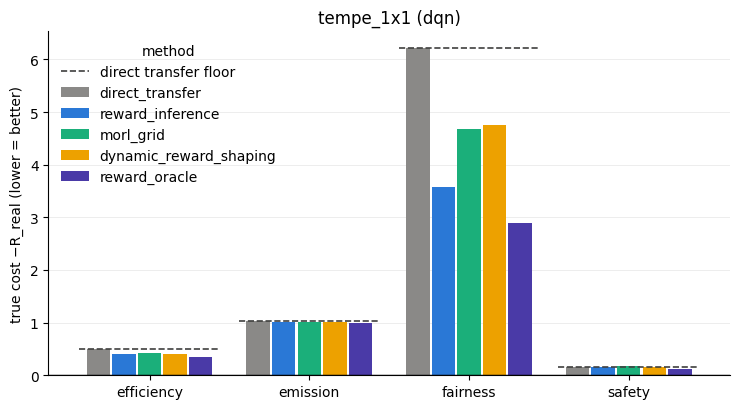

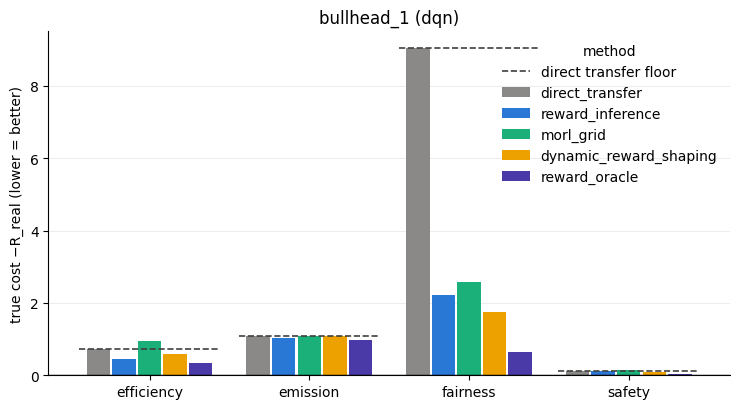

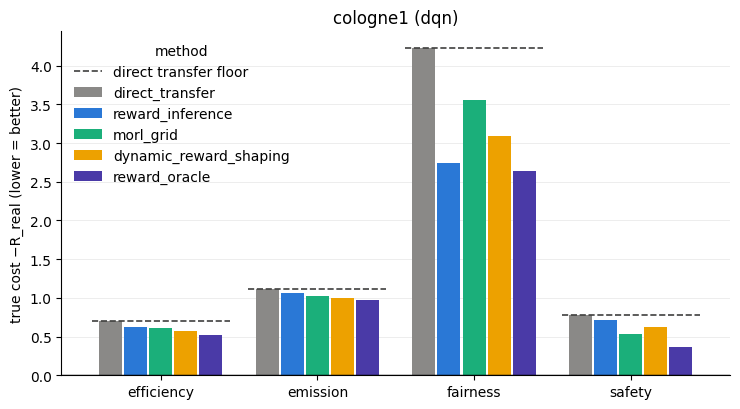

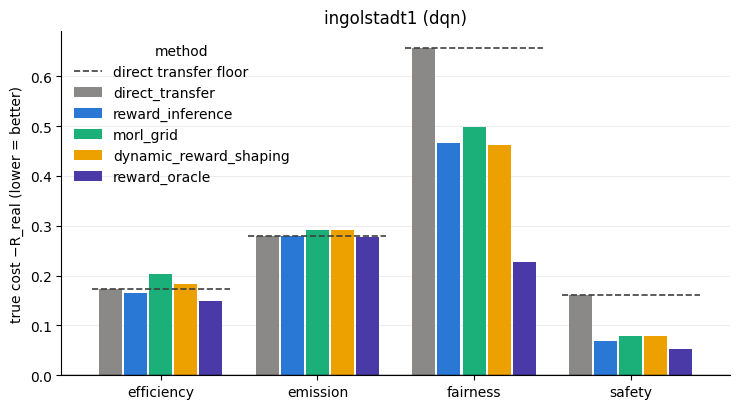

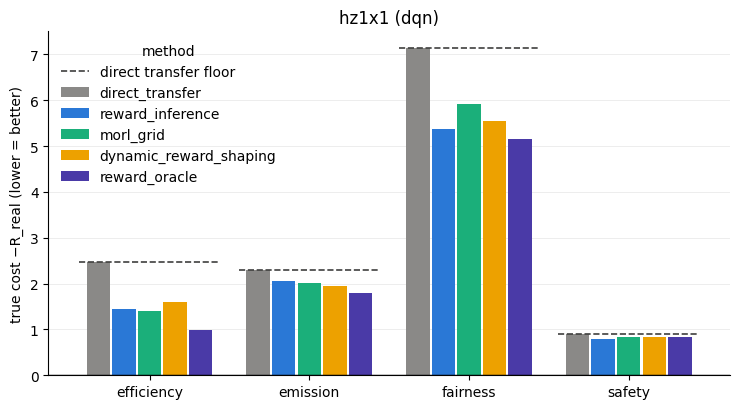

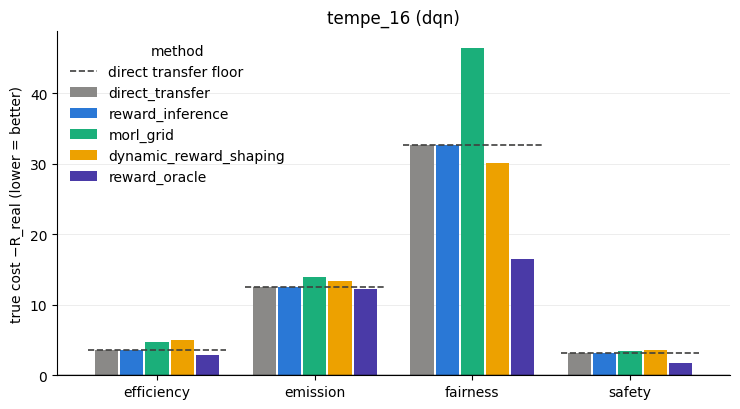

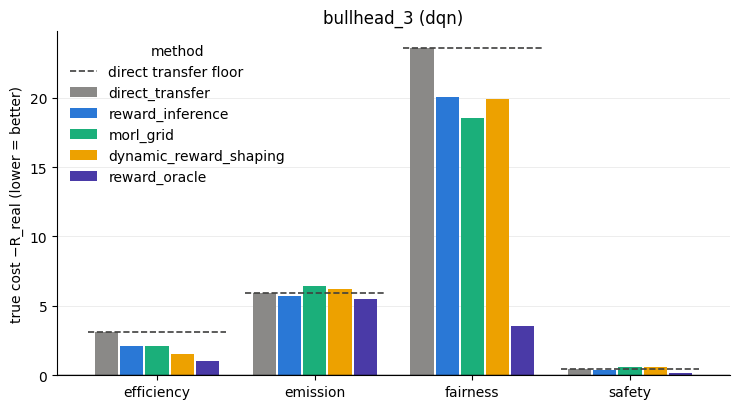

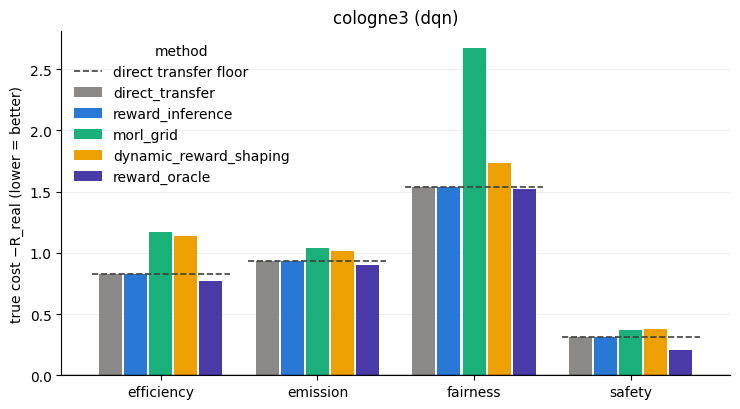

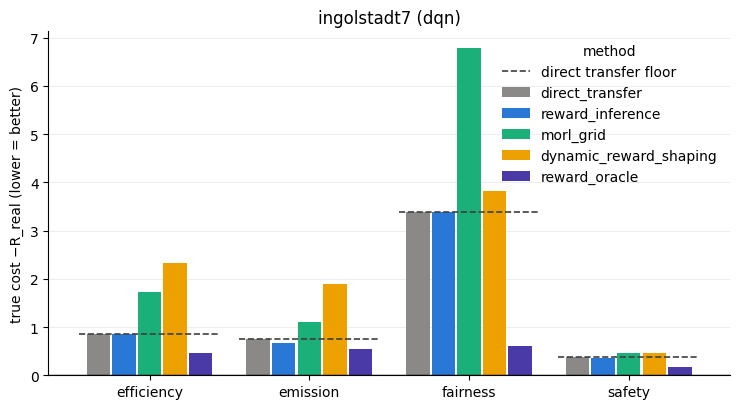

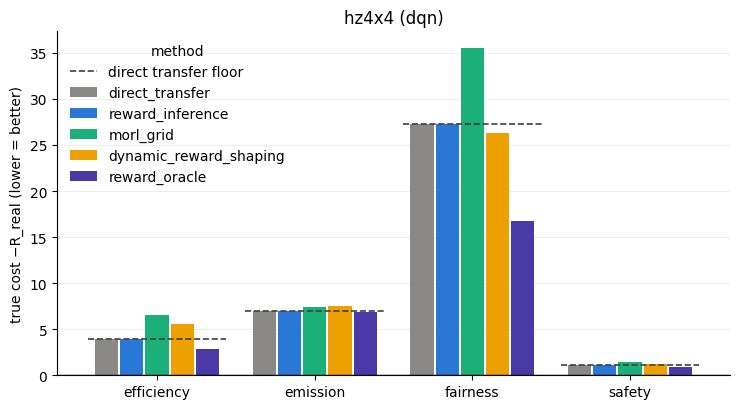

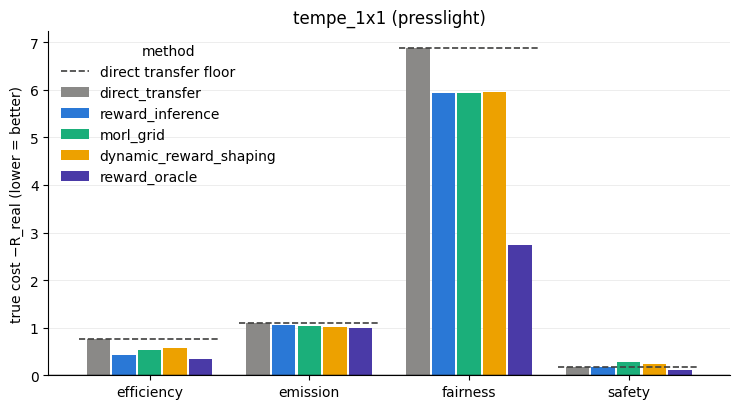

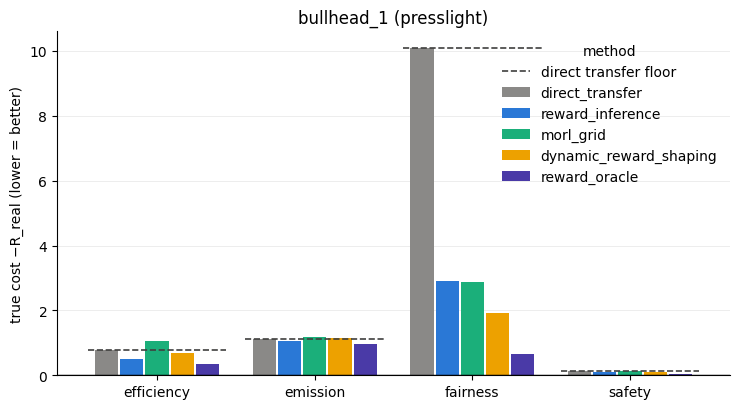

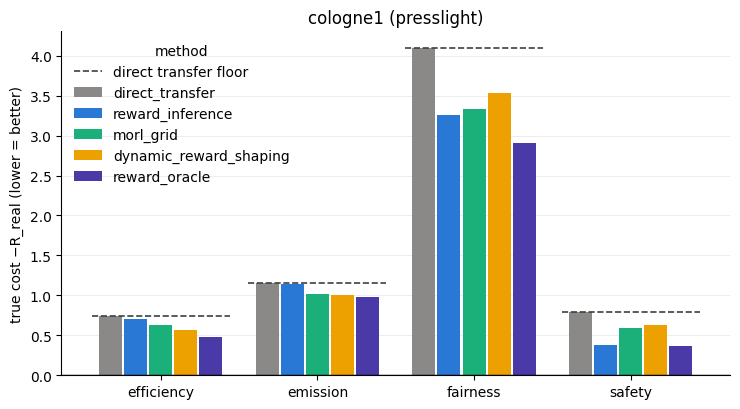

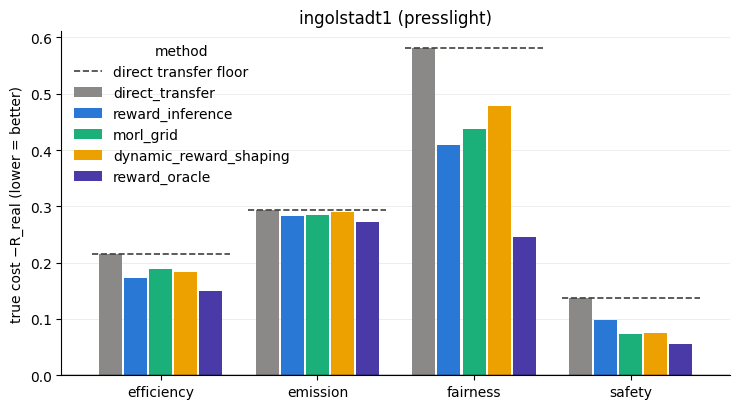

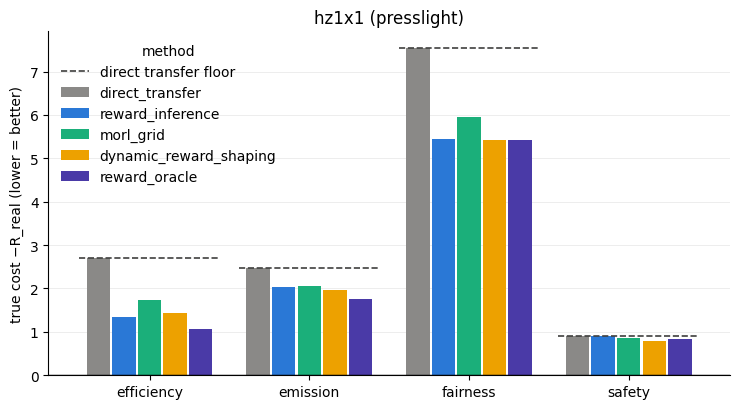

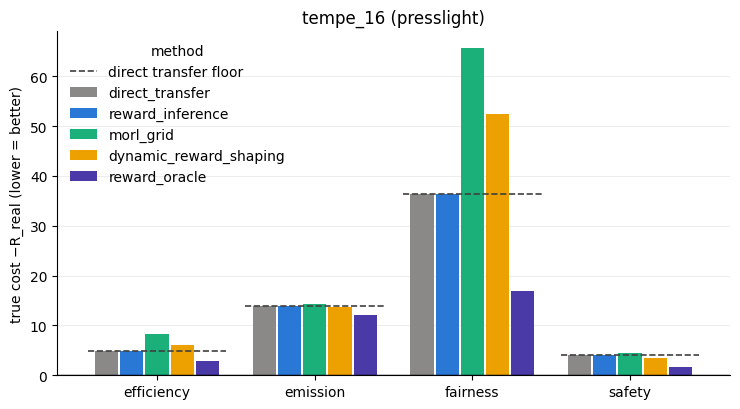

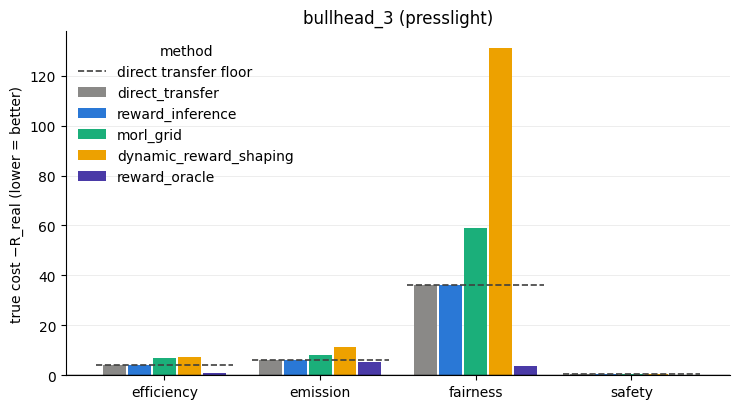

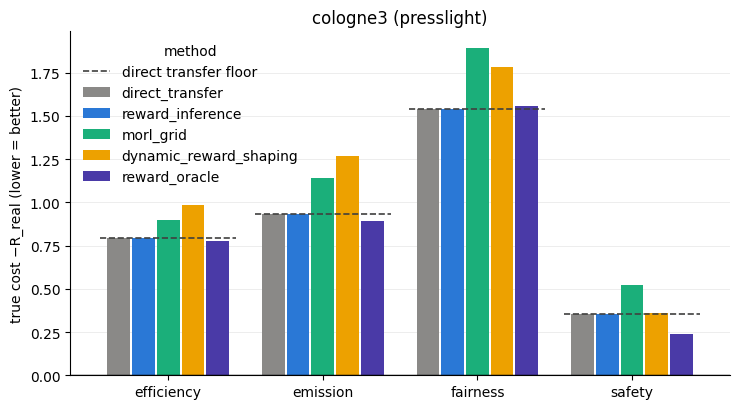

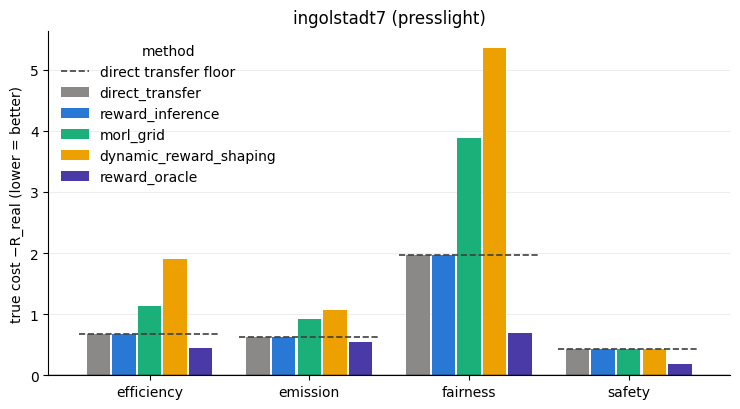

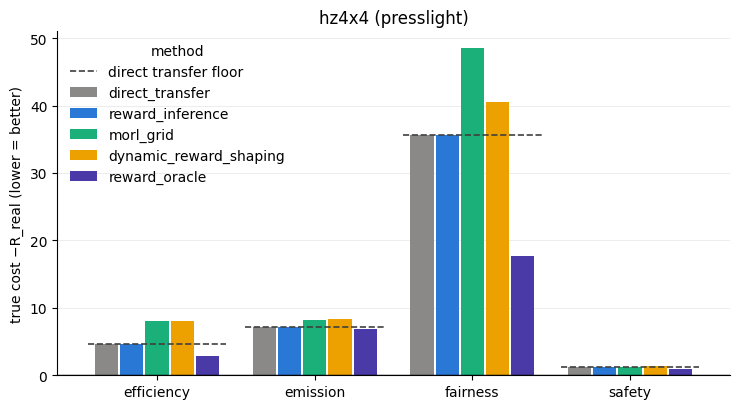

In [10]:
import matplotlib.pyplot as plt

# validated categorical slots (palette checks pass on white); direct_transfer stays a
# deliberate neutral gray — it is the de-emphasized floor reference (also echoed as the
# dashed line and present in every table), not a contending series
METHOD_COLORS = {
    'direct_transfer': '#8a8987',
    'reward_inference': '#2a78d6',
    'morl_grid': '#1baf7a',
    'dynamic_reward_shaping': '#eda100',
    'reward_oracle': '#4a3aa7',
}

FIGURE_DIR = Path('figures/reward_gap_bar_chart')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

x = np.arange(len(SETTING_ORDER))
width = 0.8 / len(METHOD_ORDER)

for agent in AGENTS:
    for network in NETWORK_ORDER:
        plot_df = results_df[(results_df['agent'] == agent) & (results_df['network'] == network)]
        if plot_df.empty:
            continue
        pivot_df = (-plot_df.pivot(index='setting', columns='method', values='R_real')
                    .reindex(SETTING_ORDER))

        fig, ax = plt.subplots(figsize=(7.5, 4.2))
        for idx, method in enumerate(METHOD_ORDER):
            if method not in pivot_df.columns:
                continue
            values = pd.to_numeric(pivot_df[method], errors='coerce').to_numpy(dtype=float)
            mask = ~np.isnan(values)
            ax.bar((x - 0.4 + width / 2 + idx * width)[mask], values[mask],
                   width=width * 0.92, color=METHOD_COLORS[method], label=method)

        # dashed floor line at the direct_transfer cost, per setting group
        dt_values = pd.to_numeric(pivot_df['direct_transfer'], errors='coerce').to_numpy(dtype=float)
        dt_mask = ~np.isnan(dt_values)
        ax.hlines(dt_values[dt_mask], (x - 0.44)[dt_mask], (x + 0.44)[dt_mask],
                  linestyles='--', colors='#40403e', linewidth=1.2,
                  label='direct transfer floor', zorder=3)

        ax.axhline(0, color='black', linewidth=1)
        ax.set_xticks(x)
        ax.set_xticklabels([SETTING_LABELS[s] for s in SETTING_ORDER])
        ax.set_ylabel('true cost −R_real (lower = better)')
        ax.set_title(f'{network} ({agent})')
        ax.legend(title='method', frameon=False)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', linewidth=0.4, alpha=0.4)
        ax.set_axisbelow(True)
        fig.tight_layout()
        fig.savefig(FIGURE_DIR / f'{agent}_{network}.png', dpi=150)
        plt.show()


## Paper-layout table CSVs

Portable CSVs in the paper-table layout — one file per (agent, setting, scale): columns = networks, rows = metric × method, with a `unit` column. **All** logged real-side metrics are included (appendix wants every number); formatting (bold-best, ±) happens at typesetting time. Units per `trainer/rewards/base.py`: emission/fuel are **episode-total kg** (accumulated, not averaged); conflicts is the **episode-total count** of TTC < 1.5 s leader-follower encounters (the collision proxy); fairness is the max–min served-vehicle spread. Single seed, so no ± — rerun `slurm/run_rewards.sbatch` with `SEED=1,2` for error bars. Written to `tables/reward_gap/*.csv`; `reward_table.csv` at the repo root stays the tidy long-format source.

In [ ]:
# The per-(agent, setting, scale) layout CSVs are written by build_reward_tables()
# in the setup cell (tables/reward_gap/*.csv). Preview one:
pd.read_csv('tables/reward_gap/dqn_physical_safety_heavy_single.csv')
